# Crop Yield Prediction - Regression Analysis

**Dataset:** `crop_yield.csv`, per-field agriculture data (region, soil type, crop, weather, farming practices) with a continuous target, `Yield_tons_per_hectare`. Regression task, not the house price dataset from class.

**Goal:** compare `SGDRegressor` (gradient descent) against `LinearRegression`, `DecisionTreeRegressor`, and `RandomForestRegressor`, pick whichever does best, and save it plus a small prediction script (`predict.py`).

In [16]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [17]:
df = pd.read_csv("crop_yield.csv")
df = df.sample(100000, random_state=42).reset_index(drop=True)
df.shape

(100000, 10)

In [18]:
df.info()
df.describe()
df.isnull().sum()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  100000 non-null  str    
 1   Soil_Type               100000 non-null  str    
 2   Crop                    100000 non-null  str    
 3   Rainfall_mm             100000 non-null  float64
 4   Temperature_Celsius     100000 non-null  float64
 5   Fertilizer_Used         100000 non-null  bool   
 6   Irrigation_Used         100000 non-null  bool   
 7   Weather_Condition       100000 non-null  str    
 8   Days_to_Harvest         100000 non-null  int64  
 9   Yield_tons_per_hectare  100000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 6.3 MB


Region                         4
Soil_Type                      6
Crop                           6
Rainfall_mm               100000
Temperature_Celsius        99999
Fertilizer_Used                2
Irrigation_Used                2
Weather_Condition              3
Days_to_Harvest               90
Yield_tons_per_hectare     99999
dtype: int64

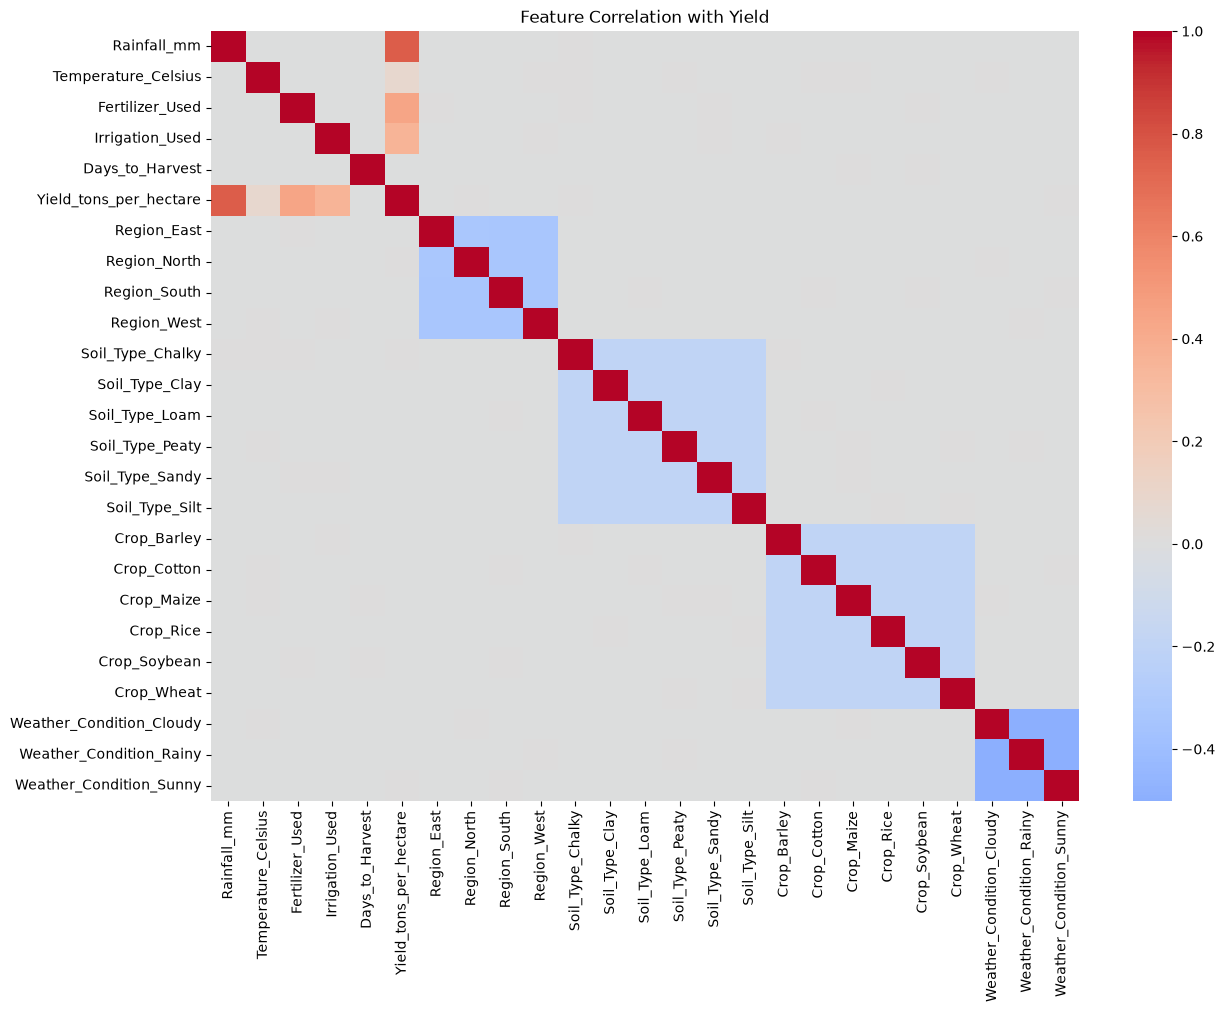

In [19]:
d = df.copy()
d['Fertilizer_Used'] = d['Fertilizer_Used'].astype(int)
d['Irrigation_Used'] = d['Irrigation_Used'].astype(int)
d = pd.get_dummies(d, columns=['Region','Soil_Type','Crop','Weather_Condition'])
plt.figure(figsize=(14,10))
sns.heatmap(d.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Yield'); plt.show()

**Correlation heatmap.** `Rainfall_mm`, `Fertilizer_Used`, and `Irrigation_Used` have the strongest correlation with `Yield_tons_per_hectare`, which makes sense, more water and fertilizer should mean more yield. `Days_to_Harvest` is basically 0 correlation with everything so it's getting dropped next. `Temperature_Celsius` and the categorical columns are weaker but not zero, so keeping them for now and checking the feature weights later to see if they actually matter.

In [ ]:
df[['Rainfall_mm','Temperature_Celsius','Days_to_Harvest','Yield_tons_per_hectare']].hist(figsize=(12,8), bins=40)
plt.show()
# the important scatter plot
sns.scatterplot(data=df.sample(3000), x='Rainfall_mm', y='Yield_tons_per_hectare', alpha=0.3)
plt.show()

**Distributions.** `Rainfall_mm`, `Temperature_Celsius`, and `Yield_tons_per_hectare` all look roughly symmetric with no crazy skew or outliers, so no need to transform anything. `Days_to_Harvest` looks pretty much uniform, which backs up dropping it. The rainfall vs yield scatter shows a clear positive line with the spread staying about the same, which is what you want to see before using a linear model.

In [ ]:
df = df.drop(columns=['Days_to_Harvest'])   # ~0 correlation, not useful
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)
df = pd.get_dummies(df, columns=['Region','Soil_Type','Crop','Weather_Condition'], drop_first=True)

In [22]:
X = df.drop(columns=['Yield_tons_per_hectare'])
y = df['Yield_tons_per_hectare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)         # transform test

In [ ]:
models = {
  'LinearRegression (OLS)': LinearRegression(),
  'SGDRegressor (gradient descent)': SGDRegressor(max_iter=1000, random_state=42),
  'DecisionTree': DecisionTreeRegressor(random_state=42),
  'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
}
results = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    pred = m.predict(X_test_s)
    results[name] = {'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}
results_df = pd.DataFrame(results).T

# whichever model has the lowest MSE wins
best_name = results_df['MSE'].idxmin()
best_model = models[best_name]

print(results_df)
print("\nWinner:", best_name)




Linear Regression (OLS) is the best model here. It has the lowest test MSE (0.2482), the highest R² (0.9139, so it explains about 91% of the variance), and it basically tied with SGD, which means gradient descent converged to the same answer and the relationship really is linear. Both linear models beat the tree models, so the extra complexity from trees didn't actually help on this data. OLS is simpler than SGD and easier to interpret, so that's the one going into deployment.

In [ ]:
# get feature weights, works whether the winner is linear or tree-based
if hasattr(best_model, 'coef_'):
    weight = pd.Series(best_model.coef_, index=X.columns, name='coefficient')
elif hasattr(best_model, 'feature_importances_'):
    weight = pd.Series(best_model.feature_importances_, index=X.columns, name='importance')

top10 = weight.reindex(weight.abs().sort_values(ascending=False).index).head(10)
print(top10)

plt.figure(figsize=(8,6))
top10.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title(f'Top 10 Feature Weights ({best_name})')
plt.tight_layout(); plt.show()

**Feature weights.** Looking at the standardized coefficients, `Rainfall_mm` (~1.30) is way bigger than everything else, then `Fertilizer_Used` (~0.75) and `Irrigation_Used` (~0.60), then `Temperature_Celsius` (~0.14) trailing behind. All the region/soil/crop/weather dummy variables are under 0.005, so they basically don't matter once rainfall and farming practices are in the model. So rainfall, fertilizer, and irrigation are what actually drive yield here, the categorical columns are just along for the ride.

In [ ]:
from sklearn.model_selection import GridSearchCV

# tuning the learning rate (and a couple other params)
param_grid = {
    'eta0': [0.001, 0.01, 0.1],          
    'max_iter': [500, 1000, 2000],
    'penalty': ['l2', None],
}
grid = GridSearchCV(
    SGDRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3
)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

# check how the tuned model does on the test set
tuned_sgd = grid.best_estimator_
tuned_pred = tuned_sgd.predict(X_test_s)
print("Tuned SGD test MSE:", mean_squared_error(y_test, tuned_pred))

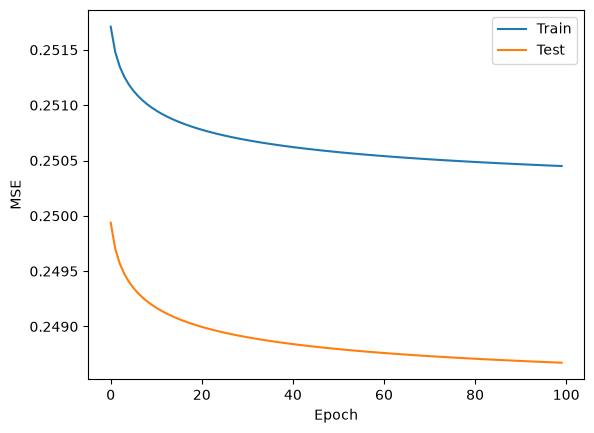

In [25]:
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42)
train_loss, test_loss = [], []
for epoch in range(100):
    sgd.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd.predict(X_test_s)))
plt.plot(train_loss, label='Train'); plt.plot(test_loss, label='Test')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()

**Loss curve.** Train and test MSE both drop fast in the first 10-20 epochs then flatten out and stay close together, no gap opening up between them. If this was overfitting you'd expect test loss to start climbing back up while train keeps going down, but that's not happening, it just settles around the same MSE as OLS (~0.25) and stays there.

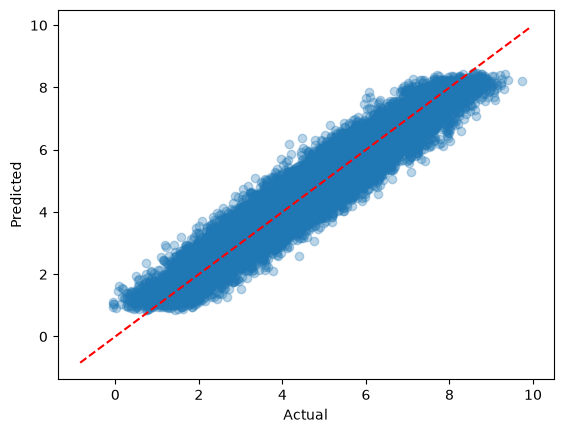

In [26]:
best_pred = models['LinearRegression (OLS)'].predict(X_test_s)
plt.scatter(y_test, best_pred, alpha=0.3)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.show()

**Actual vs predicted.** Points stick close to the 45-degree line across the whole range, no weird curve or fan shape, no obvious bias at either end. Matches the R² of ~0.91 from before, the leftover scatter just looks like noise instead of a pattern the model is missing.

In [ ]:
# best_name/best_model got picked automatically above (lowest MSE), not hardcoded.
# this cell just saves that model.
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')  # need this to scale new rows later
joblib.dump(X.columns.tolist(), 'feature_columns.joblib')  # so predict.py can line up columns
print("Saved best model:", best_name)

In [28]:
one = X_test_s[0].reshape(1,-1)
print("Predicted:", best_model.predict(one)[0], "| Actual:", y_test.iloc[0])

Predicted: 3.5379100987241863 | Actual: 3.119083993


In [ ]:
import numpy as np

# just fitting rainfall alone here so it's easy to plot as one line
from sklearn.linear_model import LinearRegression
rain = X_train['Rainfall_mm'].values.reshape(-1,1)
lin1 = LinearRegression().fit(rain, y_train)

# 100k points would be way too much to plot so just sampling some
samp = X_test.sample(2000, random_state=42)
x_plot = samp['Rainfall_mm'].values.reshape(-1,1)
y_plot = y_test.loc[samp.index]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# just the raw points, no line yet
ax[0].scatter(x_plot, y_plot, alpha=0.3, color='steelblue')
ax[0].set_title('Before: Rainfall vs Yield (raw)')
ax[0].set_xlabel('Rainfall (mm)'); ax[0].set_ylabel('Yield (t/ha)')

# same points but now with the line on top
line_x = np.linspace(rain.min(), rain.max(), 100).reshape(-1,1)
line_y = lin1.predict(line_x)
ax[1].scatter(x_plot, y_plot, alpha=0.3, color='steelblue')
ax[1].plot(line_x, line_y, color='red', linewidth=2)
ax[1].set_title('After: Fitted Linear Line Through Data')
ax[1].set_xlabel('Rainfall (mm)'); ax[1].set_ylabel('Yield (t/ha)')

plt.tight_layout(); plt.show()

**Note:** the red line here is from a separate, single-feature `LinearRegression` fit on just `Rainfall_mm`, only so it's possible to actually draw a line in 2D. The real saved model (`best_model`) uses all the features and can't be drawn as one line. Still shows the same idea though: yield goes up roughly linearly with rainfall, matching rainfall being the biggest feature weight from earlier.